### Goal: Predict Risky Drinking 0/1 based on other features, including ACEs
Develop a feedforward neural network with sigmoid activation for binary classification to predict Risky Drinking status. Use the cross entropy loss to measure loss. 

### <b>I. Setup</b> 
Load in libraries.

In [13]:
# standard
import pandas as pd
import numpy as np
import random
import os

# tf and keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras import models
from keras import layers
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence
import tensorflow_datasets as tfds

# sklearn
from sklearn import ensemble
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

# plots
import seaborn as sns
import matplotlib.pyplot as plt

random.seed(0)
%matplotlib inline

### <b>II. Prepare data</b> 
Access data and perform pre-processing.

In [14]:
def data_reader(data_list):
    """ iterates through names of .csv files and saves them to pandas dfs. """
    dfs={}
    
    for i in data_list:
        df = pd.read_csv(i + '.csv')
        dfs[i]=df  

    return dfs

In [15]:
# read in data. make pandas dfs
datasets = ['cleaned_x_train', 'cleaned_y_train', 'cleaned_x_val',  'cleaned_y_val', 'cleaned_x_test', 'cleaned_y_test' ]
dfs = data_reader(datasets)

# scale x features
scaler = StandardScaler()
x_train = scaler.fit_transform(dfs['cleaned_x_train'])
x_val = scaler.transform(dfs['cleaned_x_val'])
x_test = scaler.transform(dfs['cleaned_x_test'])

# renaming and converting to numpy arrays for y
# multiply by 1 so they say 1/0 instead of True/False
y_train = dfs['cleaned_y_train'].to_numpy()*1
y_val = dfs['cleaned_y_val'].to_numpy()*1
y_test = dfs['cleaned_y_test'].to_numpy()*1

### <b>III. Build model</b> 
Implement a feedforward neural network for tabular data, using sigmoid activation for binary classification.

In [21]:
def build_model(n_classes=2,
                hidden_layer_sizes=[144,60,48,36,24,12],
                activation='relu',
                optimizer='SGD',
                learning_rate=0.01,
                metrics=['accuracy']):

    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    model = tf.keras.Sequential()

    # neural net layers
    for i, units in enumerate(hidden_layer_sizes):
        if i == 0:
            # first layer with special initialization
            model.add(tf.keras.layers.Dense(
                units=units,
                activation=activation,
                input_shape=(x_train.shape[1],),
                use_bias=True,
                kernel_initializer='glorot_uniform',
                bias_initializer='zeros'))
        else:
            # hidden layers
            model.add(tf.keras.layers.Dense(
                units=units, 
                activation=activation))
            
    # output layer -- binary classification
    model.add(tf.keras.layers.Dense(
        units=1, 
        activation='sigmoid'
    )) 

    # optimizer with learning rate
    if optimizer == 'SGD':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == 'Adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = optimizer
    
    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=metrics
    )
    
    return model

### <b>IV. Experimentation</b> 
Fit the neural network on the training data. Experiment to discover results from different parameters.


Epoch 1/50


C:\Users\doran\anaconda3\envs\ml\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


378/378 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6423 - loss: 0.6237 - val_accuracy: 0.6582 - val_loss: 0.6150
Epoch 2/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6542 - loss: 0.6138 - val_accuracy: 0.6609 - val_loss: 0.6142
Epoch 3/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6592 - loss: 0.6101 - val_accuracy: 0.6616 - val_loss: 0.6143
Epoch 4/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6614 - loss: 0.6071 - val_accuracy: 0.6564 - val_loss: 0.6154
Epoch 5/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6633 - loss: 0.6043 - val_accuracy: 0.6574 - val_loss: 0.6153
Epoch 6/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6661 - loss: 0.6018 - val_accuracy: 0.6582 - val_loss: 0.6174
Epoch 7/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6683 - loss: 0.5992 - val_accuracy: 0.6543 - val_loss: 0.6186
Epoch 8/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6720 - loss: 0.5964 - val_accuracy: 0.6557 - val_

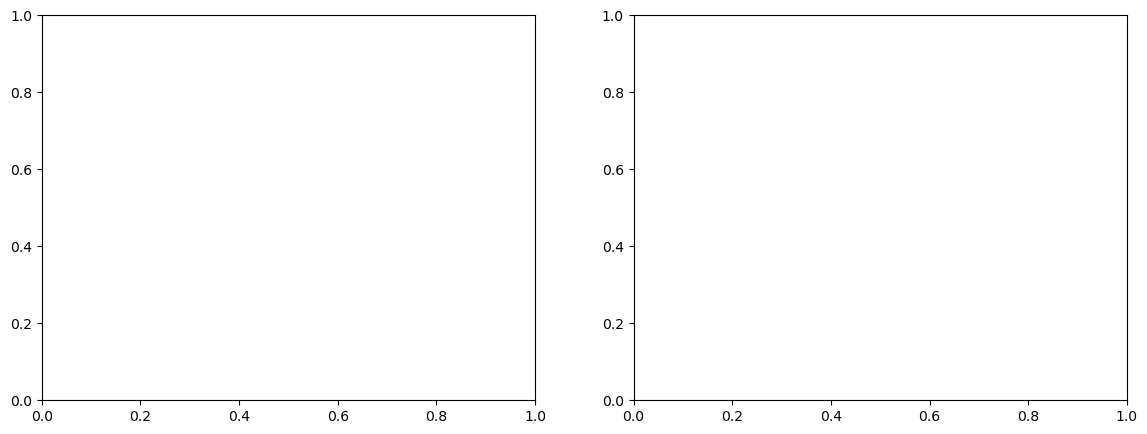

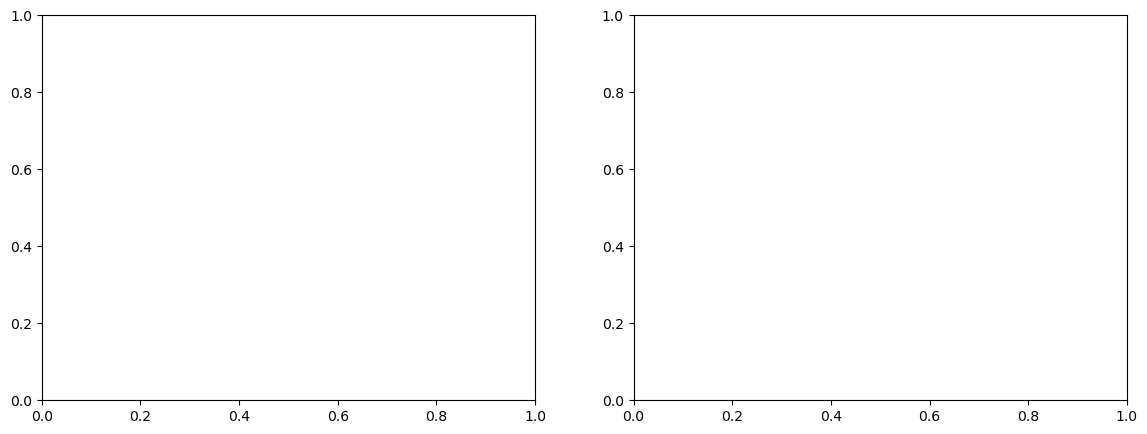

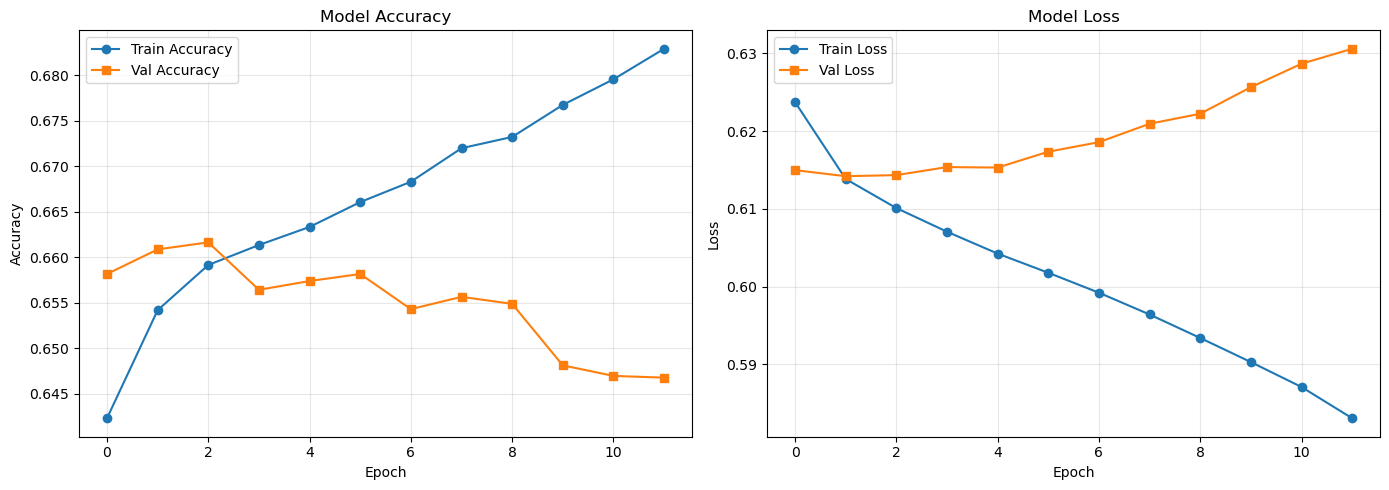


Final Training Accuracy:   0.6829
Final Validation Accuracy: 0.6468
Final Training Loss:       0.5831
Final Validation Loss:     0.6306

TEST SET EVALUATION
Test Accuracy: 0.6608
Test Loss:     0.6092

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.84      0.75      3225
           1       0.58      0.37      0.45      1952

    accuracy                           0.66      5177
   macro avg       0.63      0.60      0.60      5177
weighted avg       0.65      0.66      0.64      5177



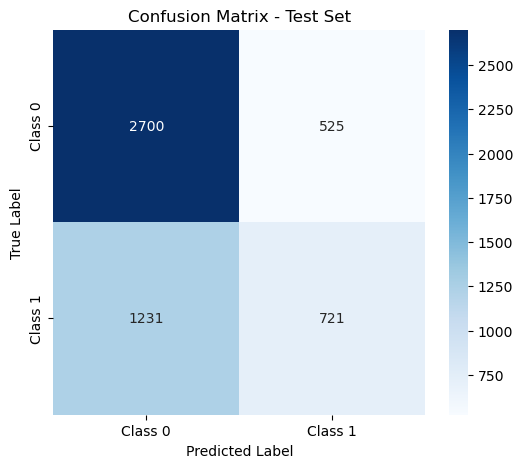

In [22]:
def train_and_evaluate(hidden_layer_sizes=[64, 32],
                       activation='relu',
                       optimizer='Adam',
                       learning_rate=0.001,
                       metrics=['accuracy'],
                       num_epochs=10,
                       batch_size=64,
                       early_stopping=False,
                       patience=5):
    """ create a model, fit it to the training data, and look at evaluation results """   
    
    # build model
    model = build_model(
        n_classes=2,
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        optimizer=optimizer,
        metrics=metrics,
        learning_rate=learning_rate)

    # set up callbacks
    callbacks = []
    if early_stopping:
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True)
        callbacks.append(early_stop)

    # train the model
    history = model.fit(
        x=x_train,
        y=y_train,
        shuffle=True,
        epochs=num_epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        callbacks=callbacks,
        verbose=1)
    
    # accuracy plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # loss plot
    axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
    axes[1].plot(history.history['val_loss'], label='Val Loss', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Model Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # print final metrics
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    print('\n')
    print(f'Final Training Accuracy: {train_acc:.4f}')
    print(f'Final Validation Accuracy: {val_acc:.4f}')
    print(f'Final Training Loss: {train_loss:.4f}')
    print(f'Final Validation Loss: {val_loss:.4f}')
    
    # evaluate on test set
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f'Test Accuracy: {test_acc:.4f}')
    print(f'Test Loss:     {test_loss:.4f}')
    
    # predictions for confusion matrix
    y_pred_probs = model.predict(x_test, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    
    # classification report
    from sklearn.metrics import classification_report, confusion_matrix
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])
    plt.title('Confusion Matrix - Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    results = {
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'test_loss': test_loss,
        'history': history.history,
        'predictions': y_pred,
        'prediction_probs': y_pred_probs}
    
    return model, results


model, results = train_and_evaluate(
    hidden_layer_sizes=[128, 64, 32],
    activation='relu',
    optimizer='Adam',
    learning_rate=0.001,
    num_epochs=50,
    early_stopping=True,
    patience=10)

### <b>V. Optimization</b> 
Use the keras tuner to optimize our model.
